# Лабораторная работа 3. ResNet18 и Self-Attention

Сравниваю обычный предобученный ResNet18 и вариант, где после последнего сверточного блока добавлен self-attention. Использую CIFAR-10, потому что он стандартный и загружается прямо из `torchvision`.


In [11]:
import os
import random
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.metrics import accuracy_score, f1_score

SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cpu


## Данные

Обе модели получают совершенно одинаковые выборки. Для быстрого запуска беру фиксированную часть CIFAR-10. Если поставить `QUICK_RUN = False`, будет использован весь набор.


In [12]:
QUICK_RUN = True
IMAGE_SIZE = 96
BATCH_SIZE = 128
EPOCHS = 5 if QUICK_RUN else 10

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(IMAGE_SIZE, padding=8),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

train_full = datasets.CIFAR10("data", train=True, download=True, transform=train_transform)
eval_full = datasets.CIFAR10("data", train=True, download=False, transform=test_transform)
test_full = datasets.CIFAR10("data", train=False, download=True, transform=test_transform)

rng = np.random.default_rng(SEED)
perm = rng.permutation(len(train_full))
if QUICK_RUN:
    train_idx = perm[:12000]
    val_idx = perm[12000:14000]
    test_idx = np.arange(3000)
else:
    train_idx = perm[:45000]
    val_idx = perm[45000:]
    test_idx = np.arange(len(test_full))

train_set = Subset(train_full, train_idx)
val_set = Subset(eval_full, val_idx)
test_set = Subset(test_full, test_idx)

def make_loaders():
    gen = torch.Generator().manual_seed(SEED)
    return (
        DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, generator=gen, num_workers=2, pin_memory=True),
        DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True),
        DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True),
    )

train_loader, val_loader, test_loader = make_loaders()
print(len(train_set), len(val_set), len(test_set))


100%|██████████| 170M/170M [43:58<00:00, 64.6kB/s]


12000 2000 3000


## Модель 1. Обычный ResNet18

Backbone уже обучен на ImageNet. Я замораживаю его и меняю только последний полносвязный слой на 10 классов.


In [13]:
def make_baseline():
    model = resnet18(weights=ResNet18_Weights.DEFAULT)
    for p in model.parameters():
        p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, 10)
    return model

baseline = make_baseline()
print("обучаемые параметры:", sum(p.numel() for p in baseline.parameters() if p.requires_grad))


обучаемые параметры: 5130


## Модель 2. ResNet18 + Self-Attention

Последняя карта признаков имеет форму `[batch, 512, h, w]`. Я считаю каждую позицию отдельным токеном, получаю последовательность `[batch, h*w, 512]` и пропускаю ее через multi-head self-attention. После этого усредняю токены и классифицирую изображение.


In [14]:
class ResNetWithAttention(nn.Module):
    def __init__(self, num_classes=10, heads=8):
        super().__init__()
        base = resnet18(weights=ResNet18_Weights.DEFAULT)
        self.encoder = nn.Sequential(*list(base.children())[:-2])
        for p in self.encoder.parameters():
            p.requires_grad = False

        self.attention = nn.MultiheadAttention(512, heads, batch_first=True)
        self.norm = nn.LayerNorm(512)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.encoder(x)                 # [B, 512, H, W]
        x = x.flatten(2).transpose(1, 2)    # [B, H*W, 512]
        attended, _ = self.attention(x, x, x, need_weights=False)
        x = self.norm(x + attended)         # residual connection
        x = x.mean(dim=1)
        return self.fc(x)

attention_model = ResNetWithAttention()
print("обучаемые параметры:", sum(p.numel() for p in attention_model.parameters() if p.requires_grad))


обучаемые параметры: 1056778


## Обучение и проверка

Loss, learning rate, число эпох, seed и данные совпадают. Сохраняю веса с лучшей accuracy на validation.


In [15]:
def run_epoch(model, loader, loss_fn, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    all_true, all_pred = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if is_train:
            optimizer.zero_grad()
        with torch.set_grad_enabled(is_train):
            logits = model(x)
            loss = loss_fn(logits, y)
            if is_train:
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * len(x)
        all_true.extend(y.cpu().numpy())
        all_pred.extend(logits.argmax(1).detach().cpu().numpy())

    return total_loss / len(loader.dataset), accuracy_score(all_true, all_pred)

def train_model(model, name):
    seed_everything(SEED)
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=1e-3, weight_decay=1e-4
    )
    best_state = None
    best_acc = -1
    history = []

    for epoch in range(EPOCHS):
        train_loss, train_acc = run_epoch(model, train_loader, loss_fn, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, loss_fn)
        history.append([train_loss, train_acc, val_loss, val_acc])
        print(f"{name} {epoch+1}/{EPOCHS}: train={train_acc:.3f}, val={val_acc:.3f}")
        if val_acc > best_acc:
            best_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model, np.array(history)

baseline, hist_base = train_model(make_baseline(), "ResNet18")
attention_model, hist_attn = train_model(ResNetWithAttention(), "ResNet18+SA")


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


ResNet18 1/5: train=0.463, val=0.613


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


ResNet18 2/5: train=0.625, val=0.646


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

ResNet18+SA 3/5: train=0.671, val=0.656


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


ResNet18+SA 4/5: train=0.679, val=0.665


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


ResNet18+SA 5/5: train=0.682, val=0.676


In [16]:
def test_model(model, loader):
    model.eval()
    true, pred = [], []
    start = time.perf_counter()
    with torch.no_grad():
        for x, y in loader:
            logits = model(x.to(device))
            true.extend(y.numpy())
            pred.extend(logits.argmax(1).cpu().numpy())
    elapsed = time.perf_counter() - start
    return {
        "accuracy": accuracy_score(true, pred),
        "macro_f1": f1_score(true, pred, average="macro"),
        "test_seconds": elapsed,
    }

rows = []
for name, model in [("ResNet18", baseline), ("ResNet18 + Self-Attention", attention_model)]:
    row = {"model": name}
    row.update(test_model(model, test_loader))
    row["trainable_parameters"] = sum(p.numel() for p in model.parameters() if p.requires_grad)
    rows.append(row)

results = pd.DataFrame(rows)
results


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,model,accuracy,macro_f1,test_seconds,trainable_parameters
0,ResNet18,0.670000,0.666024,53.174751,5130
1,ResNet18 + Self-Attention,0.666667,0.661953,56.084569,1056778


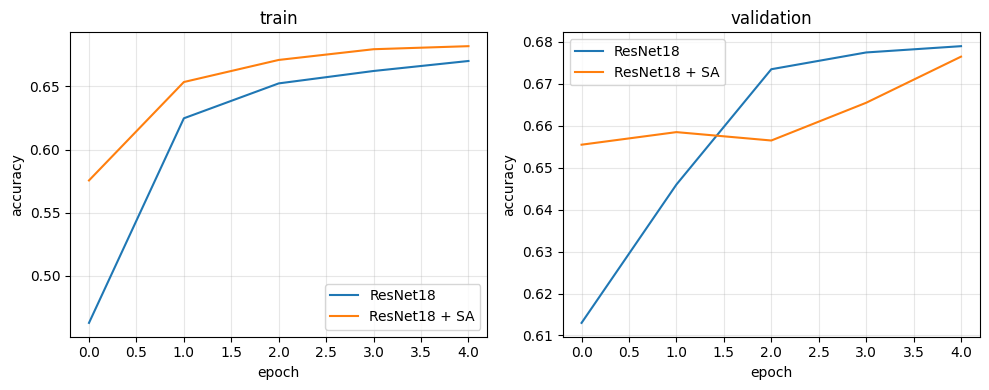

In [17]:
plt.figure(figsize=(10, 4))
for i, col in enumerate([1, 3]):
    plt.subplot(1, 2, i + 1)
    plt.plot(hist_base[:, col], label="ResNet18")
    plt.plot(hist_attn[:, col], label="ResNet18 + SA")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title("train" if col == 1 else "validation")
    plt.grid(alpha=0.3)
    plt.legend()
plt.tight_layout()


## Вывод

В результате обычная ResNet18 показала точность 67% и macro-F1 0.666. После добавления Self-Attention точность немного снизилась до 66.67%, а macro-F1 — до 0.662. При этом количество обучаемых параметров выросло с 5 130 до 1 056 778, а время тестирования увеличилось примерно с 53 до 56 секунд.

По графикам видно, что модель с Self-Attention лучше показывала себя на обучающей выборке, но на тестовой выборке улучшения не получилось. Скорее всего, более сложная модель начала сильнее подстраиваться под обучающие данные. Поэтому в данном эксперименте добавление Self-Attention не дало преимущества: обычная ResNet18 оказалась немного точнее, быстрее и намного проще.
